In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('accidents.csv', skiprows=1)
print(df.shape)
df.head()

(30, 3)


,car_safety_rating,driver_sleeping_hours,accident_happened
0,3.2,4.1,1
1,4.8,7.5,0
2,2.5,3.8,1
3,4.5,6.9,0
4,3.8,5.2,1


In [3]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

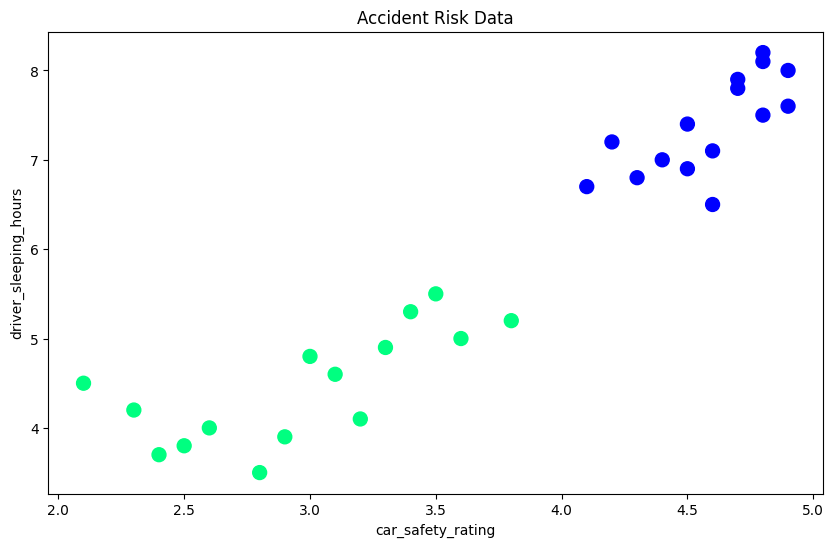

In [4]:
# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.xlabel('car_safety_rating')
plt.ylabel('driver_sleeping_hours')
plt.title('Accident Risk Data')
plt.show()

In [5]:
def step(z):
    return 1 if z > 0 else 0

In [6]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    n = X.shape[0]
    for i in range(1000):
        j = np.random.randint(0, n)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]
    return weights[0], weights[1:]

In [7]:
intercept_, coef_ = perceptron(X, y)

In [8]:
print(coef_)
print(intercept_)

[ 0.11 -0.58]
2.9000000000000017


In [9]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [10]:
x_input = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100)
y_input = m * x_input + b

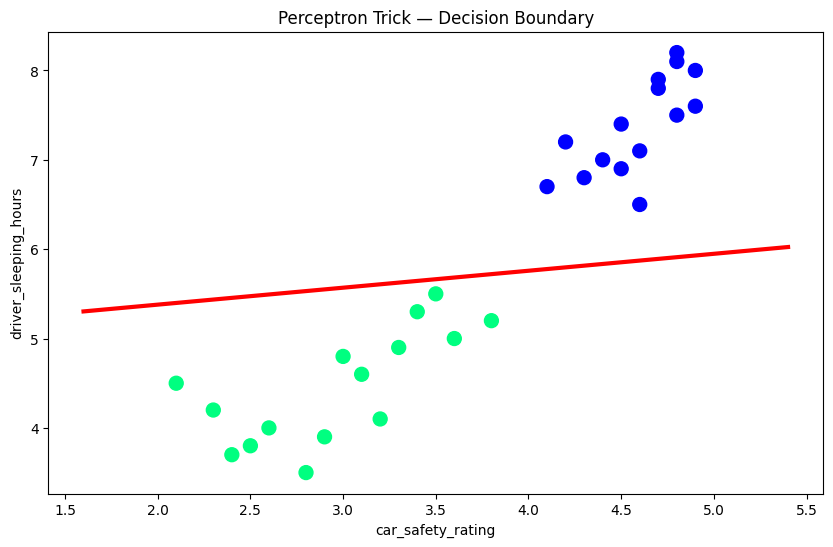

In [11]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.xlabel('car_safety_rating')
plt.ylabel('driver_sleeping_hours')
plt.title('Perceptron Trick — Decision Boundary')
plt.show()